In [1]:
# House Price Dataset: EDA + Cleaning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)
n = 5000

median_income = np.round(np.random.gamma(shape=3.0, scale=1.5, size=n), 2)          # $10k units
house_age = np.random.randint(1, 55, size=n)
avg_rooms = np.round(np.random.normal(6, 1.5, size=n).clip(2, 15), 2)
avg_bedrooms = np.round(avg_rooms * np.random.uniform(0.15, 0.3, size=n), 2)
population = np.random.randint(200, 5000, size=n)
avg_occup = np.round(np.random.normal(3, 0.8, size=n).clip(1, 8), 2)
latitude = np.round(np.random.uniform(33.5, 41.5, size=n), 3)
longitude = np.round(np.random.uniform(-124, -114, size=n), 3)

price_target = (
    0.55 * median_income
    + 0.02 * avg_rooms
    - 0.01 * house_age
    - 0.3 * avg_occup
    + np.random.normal(0, 1.2, size=n)
).clip(0.2, 5.0)
price_target = np.round(price_target, 3)

df = pd.DataFrame({
    "MedInc": median_income,
    "HouseAge": house_age,
    "AveRooms": avg_rooms,
    "AveBedrms": avg_bedrooms,
    "Population": population,
    "AveOccup": avg_occup,
    "Latitude": latitude,
    "Longitude": longitude,
    "PriceTarget": price_target,
})

# inject some real-world-style outliers in AveRooms
outlier_idx = np.random.choice(df.index, size=25, replace=False)
df.loc[outlier_idx, "AveRooms"] = np.random.uniform(20, 40, size=25)

print(df.shape)
df.head()

(5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PriceTarget
0,2.96,23,6.38,1.48,1580,1.83,41.109,-116.220,0.823
1,2.36,2,6.97,1.18,3910,5.38,37.375,-114.262,0.200
2,4.01,16,5.06,0.80,1068,3.45,34.645,-121.183,0.200
3,7.05,20,9.35,1.99,2399,2.79,41.177,-115.147,4.855
4,5.66,51,8.99,2.04,1930,1.40,34.742,-114.602,2.231


In [2]:
# Column meanings

# Inject a realistic categorical column + missing values (for cleaning practice)
np.random.seed(1)

def lat_to_region(lat):
    if lat > 38: return "NORTH"
    elif lat > 35: return "CENTRAL"
    else: return "SOUTH"

df["region"] = df["Latitude"].apply(lat_to_region)

# Randomly knock out ~3% of values in two columns to simulate real messy data
for col in ["AveBedrms", "Population"]:
    mask = np.random.rand(len(df)) < 0.03
    df.loc[mask, col] = np.nan

print("Injected missing values and a categorical column for practice.")
df.head()

Injected missing values and a categorical column for practice.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PriceTarget,region
0,2.96,23,6.38,1.48,1580.0,1.83,41.109,-116.220,0.823,NORTH
1,2.36,2,6.97,1.18,3910.0,5.38,37.375,-114.262,0.200,CENTRAL
2,4.01,16,5.06,NaN,1068.0,3.45,34.645,-121.183,0.200,SOUTH
3,7.05,20,9.35,1.99,2399.0,2.79,41.177,-115.147,4.855,NORTH
4,5.66,51,8.99,2.04,1930.0,1.40,34.742,-114.602,2.231,SOUTH


In [3]:
# Step 1 — Structure check

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       5000 non-null   float64
 1   HouseAge     5000 non-null   int32  
 2   AveRooms     5000 non-null   float64
 3   AveBedrms    4839 non-null   float64
 4   Population   4865 non-null   float64
 5   AveOccup     5000 non-null   float64
 6   Latitude     5000 non-null   float64
 7   Longitude    5000 non-null   float64
 8   PriceTarget  5000 non-null   float64
 9   region       5000 non-null   str    
dtypes: float64(8), int32(1), str(1)
memory usage: 371.2 KB


In [4]:
df.isnull().sum()

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms      161
Population     135
AveOccup         0
Latitude         0
Longitude        0
PriceTarget      0
region           0
dtype: int64

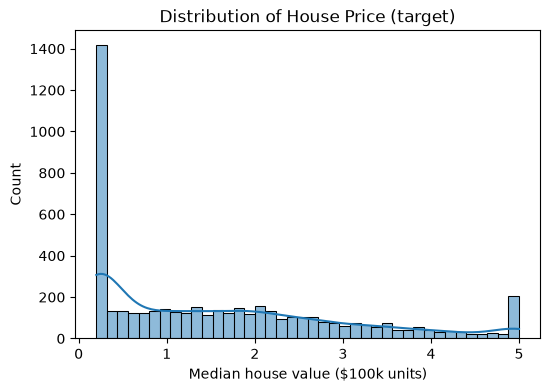

In [5]:
# Step 2 — Target distribution

plt.figure(figsize=(6,4))
sns.histplot(df["PriceTarget"], bins=40, kde=True)
plt.title("Distribution of House Price (target)")
plt.xlabel("Median house value ($100k units)")
plt.show()

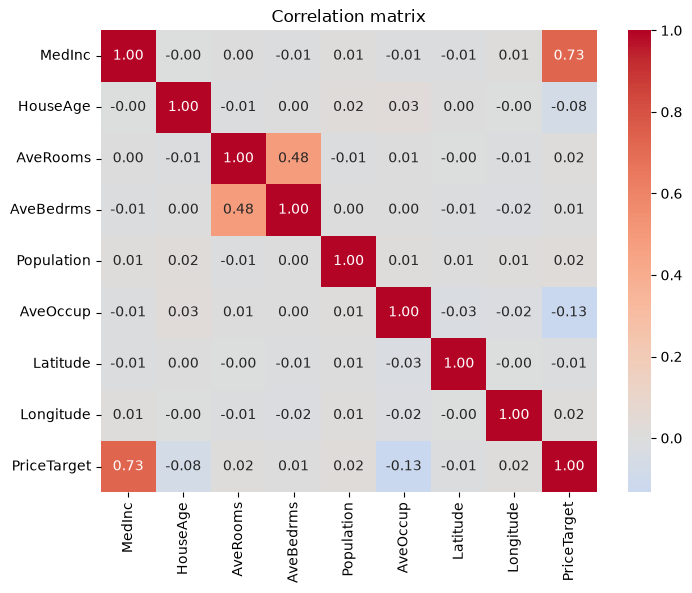


Correlation with target, sorted:
PriceTarget    1.000000
MedInc         0.732281
Population     0.017988
Longitude      0.017039
AveRooms       0.016987
AveBedrms      0.007841
Latitude      -0.007320
HouseAge      -0.075518
AveOccup      -0.133160
Name: PriceTarget, dtype: float64


In [6]:
# Step 3 — Correlation matrix

plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

print("\nCorrelation with target, sorted:")
print(corr["PriceTarget"].sort_values(ascending=False))

In [7]:
# Step 4 — Handle missing values

print("Before:")
print(df[["AveBedrms","Population"]].isnull().sum())

df["AveBedrms"] = df["AveBedrms"].fillna(df["AveBedrms"].median())
df["Population"] = df["Population"].fillna(df["Population"].median())

print("\nAfter:")
print(df[["AveBedrms","Population"]].isnull().sum())

Before:
AveBedrms     161
Population    135
dtype: int64

After:
AveBedrms     0
Population    0
dtype: int64


In [8]:
# Step 5 — Encode the categorical column

print(df["region"].value_counts())

df_encoded = pd.get_dummies(df, columns=["region"], drop_first=True)
print("\nNew columns after encoding:")
print([c for c in df_encoded.columns if "region" in c])
df_encoded.head()

region
NORTH      2192
CENTRAL    1897
SOUTH       911
Name: count, dtype: int64

New columns after encoding:
['region_NORTH', 'region_SOUTH']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PriceTarget,region_NORTH,region_SOUTH
0,2.96,23,6.38,1.48,1580.0,1.83,41.109,-116.220,0.823,True,False
1,2.36,2,6.97,1.18,3910.0,5.38,37.375,-114.262,0.200,False,False
2,4.01,16,5.06,1.31,1068.0,3.45,34.645,-121.183,0.200,False,True
3,7.05,20,9.35,1.99,2399.0,2.79,41.177,-115.147,4.855,True,False
4,5.66,51,8.99,2.04,1930.0,1.40,34.742,-114.602,2.231,False,True


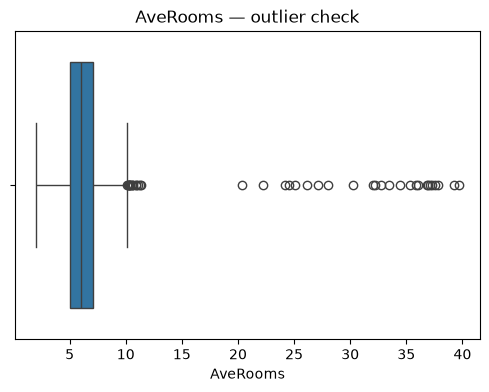

99th percentile: 9.810500000000012
Max value: 39.66992169668045


In [9]:
# Step 6 — Outlier check on key feature

plt.figure(figsize=(6,4))
sns.boxplot(x=df_encoded["AveRooms"])
plt.title("AveRooms — outlier check")
plt.show()

print("99th percentile:", df_encoded["AveRooms"].quantile(0.99))
print("Max value:", df_encoded["AveRooms"].max())

In [10]:
# To save the cleaned dataset
# Save the cleaned dataset for tomorrow (Day 3: train/test split + training)
df_encoded.to_csv("house_price_cleaned.csv", index=False)
print("Saved: house_price_cleaned.csv, shape =", df_encoded.shape)

Saved: house_price_cleaned.csv, shape = (5000, 11)
